# XWorld — Dataset 6: COVID Second Waves

Reuses already-downloaded OWID data. Extracts second waves per country.

**Expected**: Should land in Cluster 1 (same directional burst family as first wave).

In [9]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
print('Imports OK')

Imports OK


In [10]:
dest = RAW_DIR / 'owid_covid.csv'
assert dest.exists(), 'Run 01_covid_pipeline.ipynb first'

df_raw = pd.read_csv(
    dest,
    usecols=['location', 'date', 'new_cases_smoothed_per_million', 'continent'],
    parse_dates=['date']
)
df = df_raw.dropna(subset=['continent']).copy()
df = df.rename(columns={'new_cases_smoothed_per_million': 'cases_pm'})
print(f'Countries: {df.location.nunique()}')

Countries: 243


In [11]:
def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max() * 0.15, distance=45)
    if len(peaks) < 2:
        return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    end = min(peaks[1] + 60, len(s))
    wave = s[start:end]
    return wave if len(wave) >= min_days else None


second_waves = {}
for country, grp in df.groupby('location'):
    wave = extract_second_wave(grp.sort_values('date')['cases_pm'])
    if wave is not None:
        second_waves[country] = wave

print(f'Countries with usable second wave: {len(second_waves)}')

Countries with usable second wave: 209


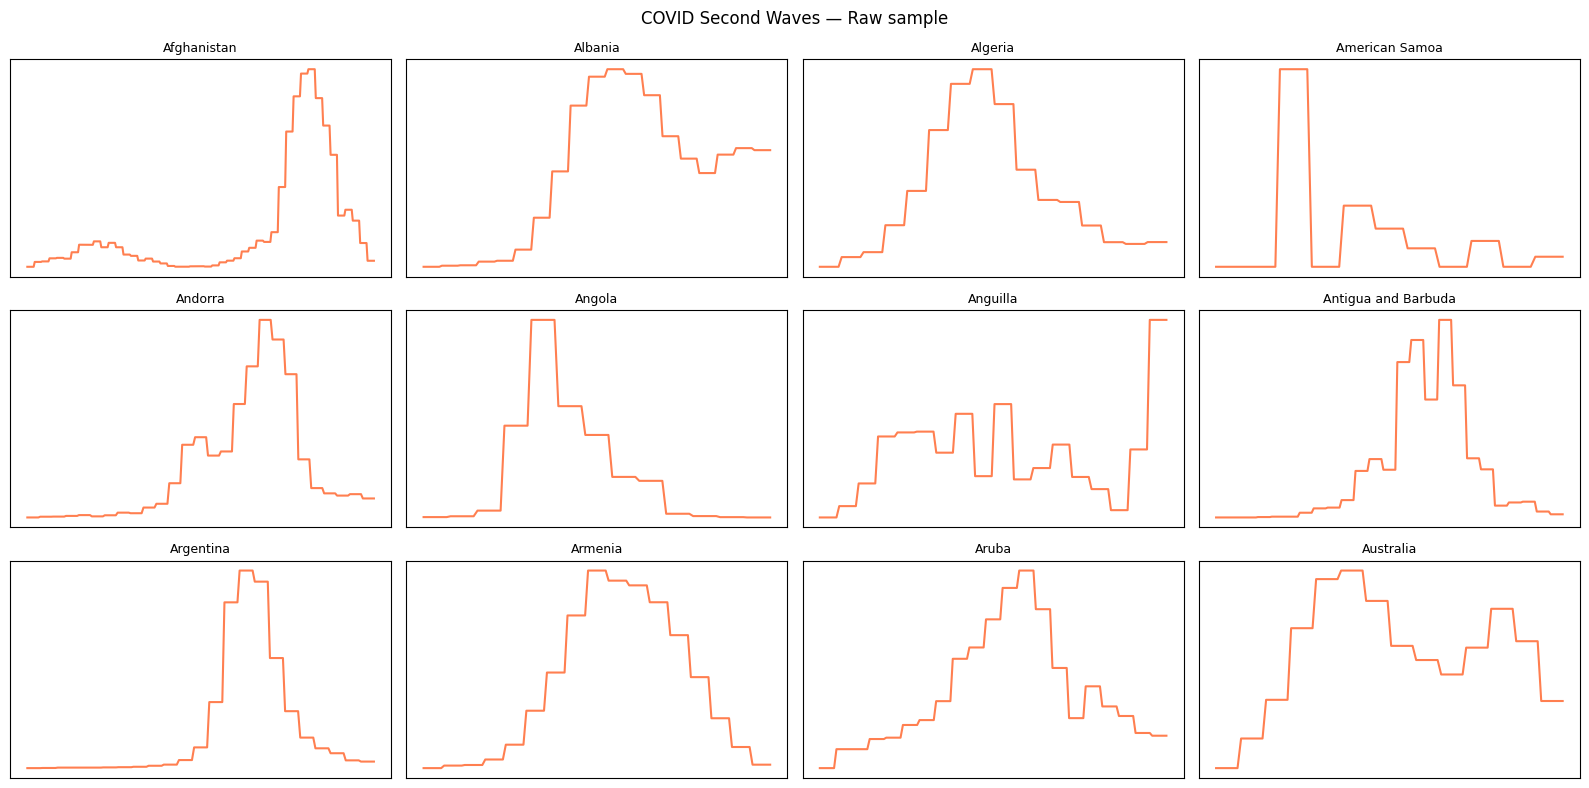

In [4]:
sample = list(second_waves.keys())[:12]
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten()
for i, country in enumerate(sample):
    axes[i].plot(second_waves[country], color='coral', linewidth=1.5)
    axes[i].set_title(country, fontsize=9)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.suptitle('COVID Second Waves — Raw sample', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'covid_second_waves_raw.png', dpi=120, bbox_inches='tight')
plt.show()

In [5]:
def zscore_normalize(s):
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()

def extract_features(series):
    n = len(series)
    t = np.arange(n)
    lag1 = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 2 else 0.0
    zc = np.sum(np.diff(np.sign(series)) != 0) / n
    slope = stats.linregress(t, series).slope
    return {
        'mean': series.mean(), 'std': series.std(),
        'skewness': stats.skew(series), 'kurtosis': stats.kurtosis(series),
        'lag1_autocorr': lag1, 'zero_crossings': zc, 'slope': slope,
    }

records = []
for country, wave in second_waves.items():
    feats = extract_features(zscore_normalize(wave))
    feats['country'] = country
    feats['dataset'] = 'covid_second_wave'
    feats['n_points'] = len(wave)
    records.append(feats)

df_features = pd.DataFrame(records)
out_path = PROCESSED_DIR / 'features_covid_second_wave.csv'
df_features.to_csv(out_path, index=False)
print(f'Saved {len(df_features)} rows to {out_path}')

Saved 209 rows to ../data/processed/features_covid_second_wave.csv
